In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [120]:
df = pd.read_csv("income.csv", usecols=["Age", "Income"])
df

,Age,Income
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


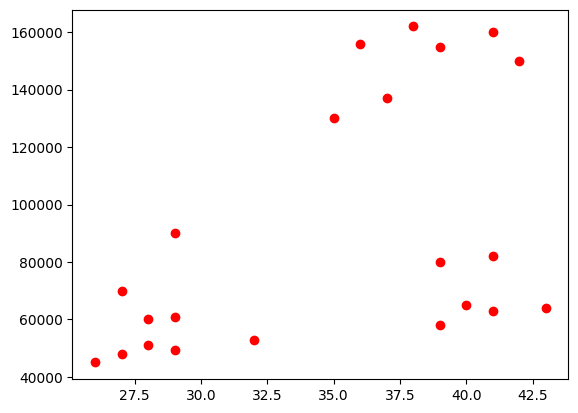

In [121]:
plt.scatter(df.Age, df.Income, color="red")

In [122]:
df.Age = df.Age.astype(int)

In [123]:
km = KMeans(n_clusters=3)
km.fit(df[["Age"]], df[["Income"]])

KMeans(n_clusters=3)

In [124]:
y_pred = km.predict(df[["Age"]])

In [125]:
df["cluster"] = y_pred
df.head()

,Age,Income,cluster
0,27,70000,2
1,29,90000,2
2,29,61000,2
3,28,60000,2
4,42,150000,1


In [126]:
df_0 = df[df.cluster == 0]
df_1 = df[df.cluster == 1]
df_2 = df[df.cluster == 2]

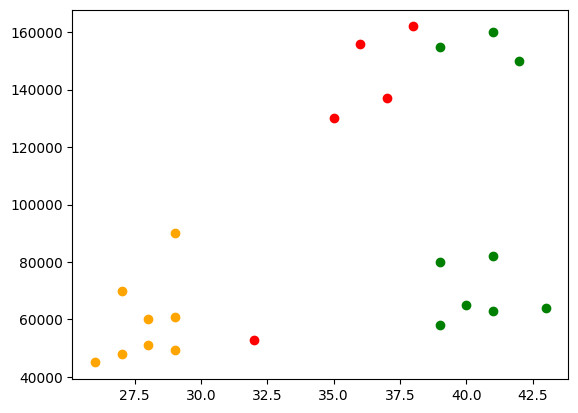

In [127]:
plt.scatter(df_0.Age, df_0.Income, color="red")
plt.scatter(df_1.Age, df_1.Income, color="green")
plt.scatter(df_2.Age, df_2.Income, color="orange")

### This clustering is not accurate as the scaling is varying in a wide range, so we can use MinMaxScaler from sklearn.preprocessing


In [128]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
df.Age = mms.fit_transform(df[["Age"]])
df.Income = mms.fit_transform(df[["Income"]])

In [129]:
df

,Age,Income,cluster
0,0.058824,0.213675,2
1,0.176471,0.384615,2
2,0.176471,0.136752,2
3,0.117647,0.128205,2
4,0.941176,0.897436,1
5,0.764706,0.940171,1
6,0.882353,0.982906,1
7,0.705882,1.000000,0
8,0.588235,0.948718,0
9,0.529412,0.726496,0


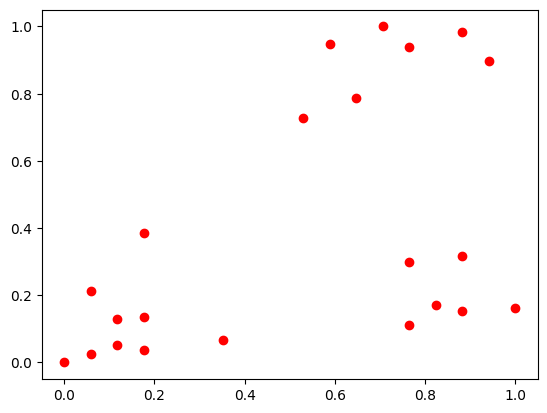

In [130]:
plt.scatter(df.Age, df.Income, color="red")

In [131]:
km = KMeans(n_clusters=3)
clusters = km.fit_predict(df[["Age", "Income"]])
clusters

array([2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [132]:
df["cluster"] = clusters
df_0 = df[df.cluster == 0]
df_1 = df[df.cluster == 1]
df_2 = df[df.cluster == 2]
df

,Age,Income,cluster
0,0.058824,0.213675,2
1,0.176471,0.384615,2
2,0.176471,0.136752,2
3,0.117647,0.128205,2
4,0.941176,0.897436,1
5,0.764706,0.940171,1
6,0.882353,0.982906,1
7,0.705882,1.000000,1
8,0.588235,0.948718,1
9,0.529412,0.726496,1


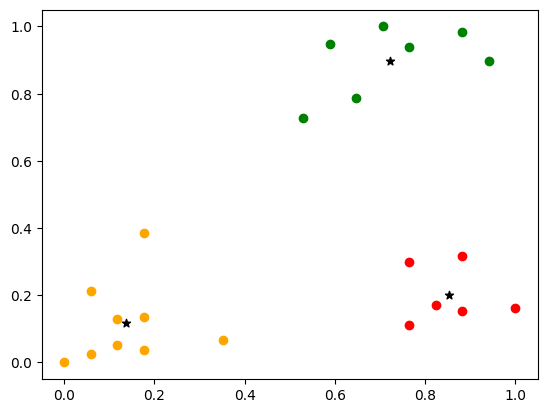

In [134]:
plt.scatter(df_0.Age, df_0.Income, color="red")
plt.scatter(df_1.Age, df_1.Income, color="green")
plt.scatter(df_2.Age, df_2.Income, color="orange")
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color="black", marker='*')

#### In above case we supplied the value on k = 3. But if we do not want to supply the of k or we have to guess that then we have to set a range of k and for each value in that k range we have to fit the model and need to compare the Sum of Squared Error. Then if we plot those SSE in a line plot then it will take a shape of elbow and at which point it bends like an elbow that will be the value of k


In [ ]:
k_range = np.arange(1, 11)
sse = []
for i in k_range:
    km = KMeans(n_clusters=i)
    km.fit(df[["Age", "Income"]])
    sse.append(km.inertia_)

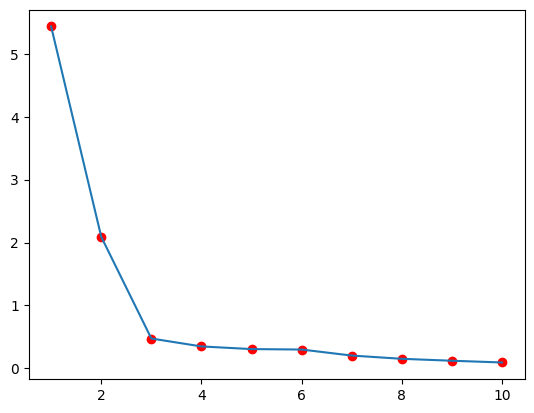

In [ ]:
plt.plot(k_range, sse)
plt.scatter(k_range, sse, color="red")
plt.xscale(value="linear")

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

In [ ]:
df = pd.DataFrame(iris.data[:, 2:4], columns=iris.feature_names[2:4])
df

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


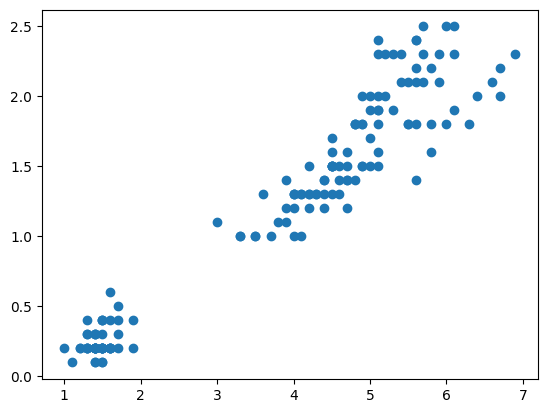

In [ ]:
plt.scatter(df[["petal length (cm)"]], df[["petal width (cm)"]])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
df[["petal length (cm)"]] = mms.fit_transform(df[["petal length (cm)"]])
df[["petal width (cm)"]] = mms.fit_transform(df[["petal width (cm)"]])
df.head()

,petal length (cm),petal width (cm)
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667


In [ ]:
# train model

k_range = np.arange(1, 11)
sse = []
for i in k_range:
    km = KMeans(n_clusters=i)
    km.fit(df[["petal length (cm)", "petal width (cm)"]])
    sse.append(km.inertia_)

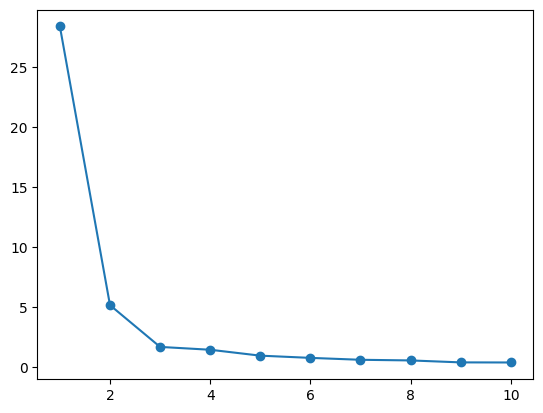

In [107]:
plt.scatter(k_range, sse)
plt.plot(k_range, sse)

In [ ]:
km = KMeans(n_clusters=3)
pred = km.fit_predict(df[["petal length (cm)", "petal width (cm)"]])
df["cluster"] = pred
df.head()

,petal length (cm),petal width (cm),cluster
0,0.067797,0.041667,1
1,0.067797,0.041667,1
2,0.050847,0.041667,1
3,0.084746,0.041667,1
4,0.067797,0.041667,1


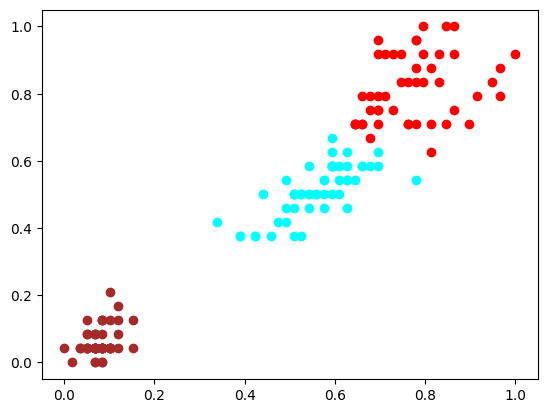

In [ ]:
df0 = df[df.cluster == 0]
df1 = df[df.cluster == 1]
df2 = df[df.cluster == 2]

plt.scatter(df0[["petal length (cm)"]], df0[["petal width (cm)"]], color="red")
plt.scatter(df1[["petal length (cm)"]], df1[["petal width (cm)"]], color="brown")
plt.scatter(df2[["petal length (cm)"]], df2[["petal width (cm)"]], color="cyan")